# Reproduce Paper I Workflow with DS1

This notebook methodologically reproduces the analysis workflow and results of Paper I, using **DS1**, a public synthetic stand-in dataset for **D1**.

*Øien, Christian Dalheim; Ringen, Geir. Data-driven through-process modelling
of aluminum extrusion: Predicting mechanical properties. Manufacturing
Letters 41 (2024), 1274–1281.
DOI: https://doi.org/10.1016/j.mfglet.2024.09.154*

Expected input file: `synthetic_data/DS1.xlsx`.

## 1. Imports and Settings

The notebook assumes it is run from the public repository root, i.e. the folder containing this notebook and the `synthetic_data` folder.

In [1]:
from pathlib import Path
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from IPython.display import display
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

REPO_DIR = Path.cwd().resolve()
DS1_FILE = REPO_DIR / "synthetic_data" / "DS1.xlsx"
OUTPUT_DIR = REPO_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

SAVE_FIGURES = False
PLOT_FOLD_ID = 4
SHOW_FOLD_METRICS = False


## 2. DS1 Schema

DS1 contains the strictly minimal columns needed for the Paper I workflow: chemistry, alloy identifier, artificial-aging recipe, measured target values, and cached NaMo-like predictions.

In [2]:
ALLOY_LABELS = {
    600524: "6005 v1",
    600563: "6005 v2",
    608226: "6082 v1",
    608227: "6082 v2",
    608260: "6082 v3",
    606385: "6063",
    606035: "6060",
}

PLOT_ORDER = ["6060", "6063", "6005 v1", "6005 v2", "6082 v1", "6082 v2", "6082 v3"]
CHEMISTRY_COLS = ["Al", "B", "Ca", "Cr", "Cu", "Fe", "Mg", "Mn", "Ni", "Si", "Ti", "V", "Zn", "Zr"]
CATEGORICAL_COLS = ["IMS", "Oven Recipe"]
TARGET_COLS = ["Rp02", "Rm"]
NAMO_COLS = ["NaMo Rp02", "NaMo Rm"]
REQUIRED_COLS = CHEMISTRY_COLS + CATEGORICAL_COLS + TARGET_COLS + NAMO_COLS

MODEL_PARAMS = {
    "objective": "reg:squarederror",
    "random_state": 13,
    "subsample": 0.8,
    "colsample_bytree": 0.5,
    "alpha": 0.1,
    "lambda": 0.9,
    "gamma": 0.01,
    "learning_rate": 0.08,
    "max_depth": 4,
    "n_estimators": 500,
    "n_jobs": 1,
    "verbosity": 0,
}


## 3. Load DS1

Loading `synthetic_data/DS1.xlsx`. If it is missing, run `generate_synthetic_data.ipynb` first.

In [4]:
def load_ds1(path):
    if not path.exists():
        raise FileNotFoundError(f"Expected DS1 workbook at {path}. Run generate_synthetic_data.ipynb first.")

    frame = pd.read_excel(path, index_col=0)
    missing = [col for col in REQUIRED_COLS if col not in frame.columns]
    if missing:
        raise ValueError(f"DS1 is missing required columns: {missing}")

    frame = frame.loc[:, REQUIRED_COLS].copy()
    # Preserve IMS as strings; synthetic generators may use string keys.
    frame["IMS"] = frame["IMS"].astype(str)

    def _map_alloy(val):
        try:
            ik = int(float(val))
        except Exception:
            return val
        return ALLOY_LABELS.get(ik, val)

    frame["alloy"] = frame["IMS"].map(_map_alloy)
    return frame

ds1 = load_ds1(DS1_FILE)
print(f"Loaded DS1 rows: {len(ds1):,}")
print(f"Loaded DS1 columns: {list(ds1.columns)}")
display(ds1.head())


Loaded DS1 rows: 9,000
Loaded DS1 columns: ['Al', 'B', 'Ca', 'Cr', 'Cu', 'Fe', 'Mg', 'Mn', 'Ni', 'Si', 'Ti', 'V', 'Zn', 'Zr', 'IMS', 'Oven Recipe', 'Rp02', 'Rm', 'NaMo Rp02', 'NaMo Rm', 'alloy']


,Al,B,Ca,Cr,Cu,Fe,Mg,Mn,Ni,Si,...,V,Zn,Zr,IMS,Oven Recipe,Rp02,Rm,NaMo Rp02,NaMo Rm,alloy
100000,98.3940,0.00122,0.00054,0.00302,0.01957,0.10371,0.66644,0.03654,0.00132,0.58857,...,0.00917,0.02191,0.00242,6082 v1,Oven Recipe 5,300.0,320.8,283.0,296.4,6082 v1
100001,98.5155,0.00099,0.00206,0.00971,0.01183,0.08279,0.56027,0.02859,0.00141,0.61126,...,0.00692,0.01702,0.00435,6005 v2,Oven Recipe 4,298.4,327.6,281.3,305.7,6005 v2
100002,98.6822,0.00181,0.00202,0.00693,0.01361,0.10532,0.46049,0.01902,0.00133,0.53511,...,0.00710,0.01207,0.00226,6005 v2,Oven Recipe 6,297.2,314.6,268.9,292.0,6005 v2
100003,99.0060,0.00179,0.00189,0.00201,0.00987,0.07453,0.30000,0.01141,0.00183,0.41931,...,0.00688,0.01651,0.00388,6060,Oven Recipe 1,236.8,262.3,245.8,270.1,6060
100004,98.5559,0.00153,0.00213,0.00651,0.01690,0.10213,0.57184,0.03765,0.00229,0.53208,...,0.00352,0.01926,0.00062,6005 v2,Oven Recipe 6,297.4,323.6,267.0,288.8,6005 v2


## 4. ML-ready input data and Cross-Validation Folds

The X_xgb dataframe below has the 27-column format presented in Paper I with one-hot encoded columns for Oven Recipe and Alloy. X_hybrid has NaMo estimates as two additional columns.

The fold construction is alloy-stratified, matching the Paper I evaluation logic. All DS1 rows are assigned to exactly one test fold.

In [12]:
def make_design_matrix(frame, include_namo):
    numeric_cols = CHEMISTRY_COLS + (NAMO_COLS if include_namo else [])
    numeric = frame.loc[:, numeric_cols].copy()
    numeric = (numeric - numeric.mean()) / numeric.std().replace(0, 1)
    categorical = pd.get_dummies(frame.loc[:, CATEGORICAL_COLS].astype(str), prefix=CATEGORICAL_COLS)
    return pd.concat([numeric, categorical], axis=1)

def make_alloy_stratified_folds(frame, group_col="IMS", n_folds=5):
    fold_indices = [[] for _ in range(n_folds)]
    for _, group in frame.groupby(group_col, sort=False):
        for fold_id, ids in enumerate(np.array_split(group.index.to_numpy(), n_folds)):
            fold_indices[fold_id].extend(ids)
    return [frame.loc[index].copy() for index in fold_indices]

X_xgb = make_design_matrix(ds1, include_namo=False)
X_hybrid = make_design_matrix(ds1, include_namo=True)
folds = make_alloy_stratified_folds(ds1)


print(f"X_xgb shape: {X_xgb.shape}")
print(f"X_hybrid shape: {X_hybrid.shape}")
print("Fold sizes:", [len(fold) for fold in folds])

X_xgb shape: (9000, 27)
X_hybrid shape: (9000, 29)
Fold sizes: [1802, 1801, 1800, 1799, 1798]


## 5. Evaluation Helpers

XGBoost and the simple hybrid are evaluated with the same hyperparameter values as Paper I. `MultiOutputRegressor` with single-threaded estimators is used to avoid version-dependent two-output XGBoost behavior and reduce notebook kernel instability.

In [6]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def metric_row(y_true, y_pred):
    return {
        "Rp02 R2": r2_score(y_true["Rp02"], y_pred["Rp02"]),
        "Rp02 RMSE": rmse(y_true["Rp02"], y_pred["Rp02"]),
        "Rm R2": r2_score(y_true["Rm"], y_pred["Rm"]),
        "Rm RMSE": rmse(y_true["Rm"], y_pred["Rm"]),
    }

def fit_xgb(X_train, y_train):
    base = xgb.XGBRegressor(**MODEL_PARAMS)
    model = MultiOutputRegressor(base, n_jobs=1)
    model.fit(X_train.to_numpy(dtype=np.float32), y_train.to_numpy(dtype=np.float32))
    return model

def predict_xgb(model, X_test, index):
    pred = model.predict(X_test.to_numpy(dtype=np.float32))
    return pd.DataFrame(pred, index=index, columns=TARGET_COLS)

def evaluate_xgb_cv(X_full, folds):
    rows = []
    for fold_id, test_fold in enumerate(folds):
        train_fold = pd.concat([fold for i, fold in enumerate(folds) if i != fold_id], axis=0)
        model = fit_xgb(X_full.loc[train_fold.index], train_fold.loc[:, TARGET_COLS])
        pred = predict_xgb(model, X_full.loc[test_fold.index], test_fold.index)
        rows.append(metric_row(test_fold.loc[:, TARGET_COLS], pred))
    return pd.DataFrame(rows, index=[f"fold_{i}" for i in range(len(folds))])

def evaluate_namo_cv(folds):
    rows = []
    for test_fold in folds:
        pred = test_fold.loc[:, NAMO_COLS].rename(columns={"NaMo Rp02": "Rp02", "NaMo Rm": "Rm"})
        rows.append(metric_row(test_fold.loc[:, TARGET_COLS], pred))
    return pd.DataFrame(rows, index=[f"fold_{i}" for i in range(len(folds))])

def evaluate_baseline_cv(folds):
    rows = []
    for fold_id, test_fold in enumerate(folds):
        train_fold = pd.concat([fold for i, fold in enumerate(folds) if i != fold_id], axis=0)
        alloy_means = train_fold.groupby("IMS")[TARGET_COLS].mean()
        pred = test_fold.loc[:, ["IMS"]].join(alloy_means, on="IMS").loc[:, TARGET_COLS]
        rows.append(metric_row(test_fold.loc[:, TARGET_COLS], pred))
    return pd.DataFrame(rows, index=[f"fold_{i}" for i in range(len(folds))])

def summarize_metrics(metrics):
    return pd.Series({
        key: f"{metrics[key].mean():.2f} +/- {2 * metrics[key].std():.3f}"
        for key in ["Rp02 R2", "Rp02 RMSE", "Rm R2", "Rm RMSE"]
    })


## 6. Summary Table

This reproduces the Paper I comparison structure on DS1: NaMo-like cached estimates, XGBoost, simple feature-augmentation hybrid, and alloy-average baseline.

In [7]:
cv_results = {
    "NaMo": evaluate_namo_cv(folds),
    "XGBoost": evaluate_xgb_cv(X_xgb, folds),
    "Hybrid": evaluate_xgb_cv(X_hybrid, folds),
    "Baseline": evaluate_baseline_cv(folds),
}

summary_table = pd.DataFrame({name: summarize_metrics(metrics) for name, metrics in cv_results.items()}).T
summary_table.index.name = "Model"
display(summary_table)
summary_table.to_csv(OUTPUT_DIR / "paper_i_DS1_results_summary.csv")

if SHOW_FOLD_METRICS:
    display(pd.concat(cv_results, names=["Model", "Fold"]))


,Rp02 R2,Rp02 RMSE,Rm R2,Rm RMSE
Model,,,,
NaMo,0.55 +/- 0.007,28.37 +/- 0.302,0.44 +/- 0.009,34.27 +/- 0.569
XGBoost,0.96 +/- 0.002,8.20 +/- 0.210,0.96 +/- 0.002,9.05 +/- 0.210
Hybrid,0.96 +/- 0.003,8.21 +/- 0.263,0.96 +/- 0.003,9.10 +/- 0.306
Baseline,0.85 +/- 0.006,16.54 +/- 0.385,0.83 +/- 0.005,18.81 +/- 0.363


## 7. Paper-Style Scatter Plots

The figures use one representative cross-validation fold and follow the same visual structure as Paper I: measured vs. predicted values with an error histogram inset.

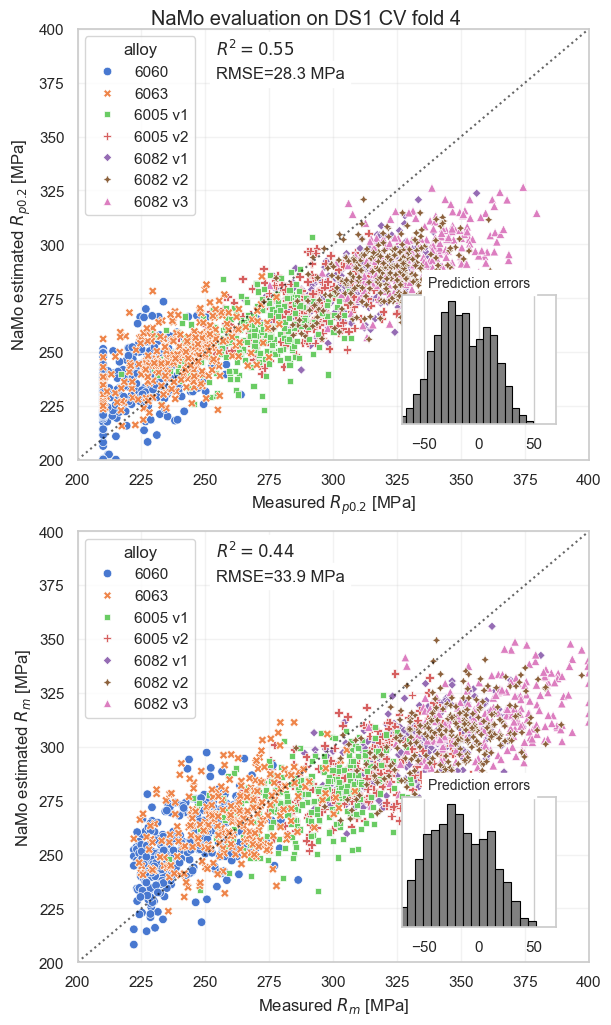

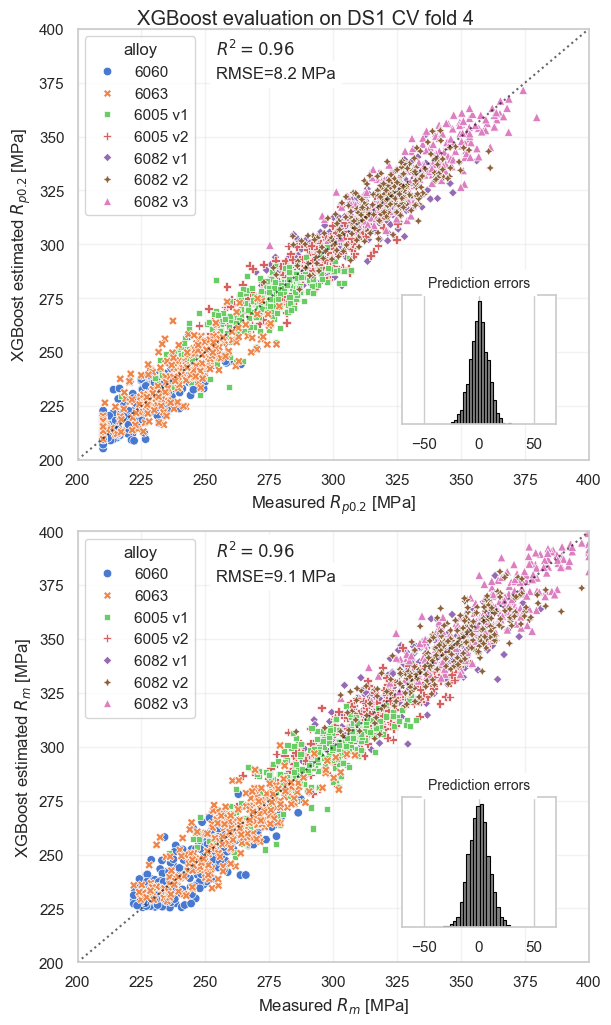

In [8]:
def predict_cv_fold(X_full, folds, fold_id):
    fold_id = min(fold_id, len(folds) - 1)
    test_fold = folds[fold_id].copy()
    train_fold = pd.concat([fold for i, fold in enumerate(folds) if i != fold_id], axis=0)
    model = fit_xgb(X_full.loc[train_fold.index], train_fold.loc[:, TARGET_COLS])
    return test_fold, predict_xgb(model, X_full.loc[test_fold.index], test_fold.index)

def model_eval_plot(df, true_col, pred_col, x_label, y_label, ax):
    order = [label for label in PLOT_ORDER if label in set(df["alloy"])]
    sns.scatterplot(
        data=df,
        x=true_col,
        y=pred_col,
        hue="alloy",
        style="alloy",
        hue_order=order,
        style_order=order,
        palette="muted",
        s=38,
        ax=ax,
    )
    ax.plot([200, 400], [200, 400], linestyle=":", color="black", alpha=0.6)
    ax.set_xlim(200, 400)
    ax.set_ylim(200, 400)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.grid(alpha=0.25)
    score = r2_score(df[true_col], df[pred_col])
    error = rmse(df[true_col], df[pred_col])
    ax.annotate(f"$R^2={score:0.2f}$", xy=(254, 388), xytext=(254, 388), backgroundcolor="white")
    ax.annotate(f"RMSE={error:0.1f} MPa", xy=(254, 377), xytext=(254, 377), backgroundcolor="white")
    inset = inset_axes(ax, width="100%", height="100%", bbox_to_anchor=(0.65, 0.1, 0.3, 0.3), bbox_transform=ax.transAxes)
    inset.hist(df[pred_col] - df[true_col], bins=20, color="gray", edgecolor="black", linewidth=0.8)
    inset.set_xlim(-70, 70)
    inset.set_ylim(bottom=0)
    inset.set_yticks([])
    inset.set_title("Prediction errors", fontsize=10, backgroundcolor="white", pad=6)

plot_fold, xgb_pred = predict_cv_fold(X_xgb, folds, PLOT_FOLD_ID)
xgb_plot_df = plot_fold.loc[:, ["alloy", "Rp02", "Rm"]].join(xgb_pred.add_prefix("XGBoost "))
namo_plot_df = plot_fold.loc[:, ["alloy", "Rp02", "Rm", "NaMo Rp02", "NaMo Rm"]]

fig_namo, axes_namo = plt.subplots(2, 1, figsize=(6, 10), constrained_layout=True)
model_eval_plot(namo_plot_df, "Rp02", "NaMo Rp02", "Measured $R_{p0.2}$ [MPa]", "NaMo estimated $R_{p0.2}$ [MPa]", axes_namo[0])
model_eval_plot(namo_plot_df, "Rm", "NaMo Rm", "Measured $R_m$ [MPa]", "NaMo estimated $R_m$ [MPa]", axes_namo[1])
fig_namo.suptitle(f"NaMo evaluation on DS1 CV fold {PLOT_FOLD_ID}", y=1.01)

fig_xgb, axes_xgb = plt.subplots(2, 1, figsize=(6, 10), constrained_layout=True)
model_eval_plot(xgb_plot_df, "Rp02", "XGBoost Rp02", "Measured $R_{p0.2}$ [MPa]", "XGBoost estimated $R_{p0.2}$ [MPa]", axes_xgb[0])
model_eval_plot(xgb_plot_df, "Rm", "XGBoost Rm", "Measured $R_m$ [MPa]", "XGBoost estimated $R_m$ [MPa]", axes_xgb[1])
fig_xgb.suptitle(f"XGBoost evaluation on DS1 CV fold {PLOT_FOLD_ID}", y=1.01)

if SAVE_FIGURES:
    fig_namo.savefig(OUTPUT_DIR / "paper_i_DS1_NaMo_results.png", dpi=300, bbox_inches="tight")
    fig_xgb.savefig(OUTPUT_DIR / "paper_i_DS1_XGBoost_results.png", dpi=300, bbox_inches="tight")
